# Neural Network with PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from numpy.typing import NDArray
from typing import Tuple
import math
import matplotlib.pyplot as plt

def load_data_npy():
    # pylint: disable=missing-function-docstring
    x = np.load("data/X.npy")
    y = np.load("data/y.npy")
    return x, y

def shuffle_data(x: NDArray, y: NDArray, m: int) -> Tuple[NDArray, NDArray]:
    # pylint: disable=missing-function-docstring
    indices = np.random.choice(x.shape[0], m, replace=False)
    return x[indices], y[indices]

def split_data(x: NDArray, y: NDArray, rate: float) -> Tuple[NDArray, NDArray, NDArray, NDArray]:
    # pylint: disable=missing-function-docstring
    m = x.shape[0]
    indices = np.random.permutation(m)
    m_sp = int(m * rate)
    m_train = indices[:m_sp]
    m_test = indices[m_sp:]
    return x[m_train], x[m_test], y[m_train], y[m_test]

x_data, y_data = load_data_npy()
# x_data, y_data = shuffle_data(x_data, y_data, 1000)
x_train, x_test, y_train, y_test = split_data(x_data, y_data, 0.8)
# x_train = x_data
# x_test = x_data
# y_train = y_data
# y_test = y_data

x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)

print (f'Shape: x_data {x_data.shape}, y_data {y_data.shape}')
print (f'Shape: x_train {x_train.shape}, y_train {y_train.shape}')
print (f'Shape: x_test {x_test.shape}, y_test {y_test.shape}')


Shape: x_data (5000, 400), y_data (5000, 1)
Shape: x_train (4000, 400), y_train (4000, 1)
Shape: x_test (1000, 400), y_test (1000, 1)


In [17]:

# # --- 1. 模拟你的数据 ---
# # 假设你有 1000 条数据，每条 400 像素
# X_raw = np.random.randn(1000, 400).astype(np.float32)
# # 假设标签是 0-9 分类 (10类)，或者是 0/1 (2类)，这里假设是 10 类
# Y_raw = np.random.randint(0, 10, (1000, 1)) 

# --- 2. 数据预处理 (关键步骤) ---
# 1. 将 400 还原为 20x20，并增加通道维度 -> (1000, 1, 20, 20)
# 注意：这里假设你的 400 是按行优先排列的，所以直接 reshape
X_tensor = torch.from_numpy(x_train).view(-1, 1, 20, 20)

# 2. 将标签压平 -> (1000,)
# PyTorch 的 CrossEntropyLoss 需要标签是一维的长整型
y_tensor = torch.from_numpy(y_train).long().squeeze()

print(f"输入形状: {X_tensor.shape}") # 应输出: torch.Size([1000, 1, 20, 20])
print(f"标签形状: {y_tensor.shape}") # 应输出: torch.Size([1000])

# --- 3. 定义 SimpleCNN ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # 输入是 1通道(灰度), 20x20 大小
        
        # 第一层卷积
        # in=1, out=16 (特征图数量), kernel=3, padding=1 (保持尺寸)
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # 2x2 池化，尺寸减半
        
        # 第二层卷积
        # in=16, out=32
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        
        # 全连接层
        # 经过两次池化：20 -> 10 -> 5
        # 所以输入维度是：32(通道) * 5(高) * 5(宽)
        self.fc1 = nn.Linear(32 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
        self.relu = nn.ReLU()

    def forward(self, x):
        # 卷积 -> 激活 -> 池化
        x = self.pool(self.relu(self.conv1(x))) # 尺寸: 20 -> 10
        x = self.pool(self.relu(self.conv2(x))) # 尺寸: 10 -> 5
        
        # 展平
        x = x.view(-1, 32 * 5 * 5)
        
        # 全连接
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# --- 4. 训练配置 ---
model = SimpleCNN(num_classes=10) # 如果是二分类，这里改为 2
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 5. 模拟训练循环 ---
print("\n开始训练...")
epochs = 1000
print_point = 10
min_delta = 1e-4
patience = 10
patience_counter = 0
loss_pre = np.inf
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # 前向传播
    outputs = model(X_tensor)
    
    # 计算损失
    loss = criterion(outputs, y_tensor)
    idx = epoch + 1
    if idx % print_point == 0:
        print(f"Epoch [{epoch+1:8d}/{epochs}], Loss: {loss.item():.4f}")
    
    # Earrly Stopping
    delta = loss_pre - loss.item()
    if delta < 0:
        break
    elif delta < min_delta:
        patience_counter += 1
        if patience_counter >= patience:
            break
    else:
        patience_counter = 0
    
    loss_pre = loss.item()

    # 反向传播
    loss.backward()
    optimizer.step()



print("训练完成！")

输入形状: torch.Size([4000, 1, 20, 20])
标签形状: torch.Size([4000])

开始训练...
Epoch [      10/1000], Loss: 2.1505
Epoch [      20/1000], Loss: 1.6815
Epoch [      30/1000], Loss: 0.9570
Epoch [      40/1000], Loss: 0.5299
Epoch [      50/1000], Loss: 0.3610
Epoch [      60/1000], Loss: 0.2731
Epoch [      70/1000], Loss: 0.2143
Epoch [      80/1000], Loss: 0.1727
Epoch [      90/1000], Loss: 0.1414
Epoch [     100/1000], Loss: 0.1171
Epoch [     110/1000], Loss: 0.0978
Epoch [     120/1000], Loss: 0.0819
Epoch [     130/1000], Loss: 0.0688
Epoch [     140/1000], Loss: 0.0577
Epoch [     150/1000], Loss: 0.0482
Epoch [     160/1000], Loss: 0.0402
Epoch [     170/1000], Loss: 0.0334
Epoch [     180/1000], Loss: 0.0277
Epoch [     190/1000], Loss: 0.0230
Epoch [     200/1000], Loss: 0.0192
Epoch [     210/1000], Loss: 0.0160
Epoch [     220/1000], Loss: 0.0135
Epoch [     230/1000], Loss: 0.0114
Epoch [     240/1000], Loss: 0.0097
Epoch [     250/1000], Loss: 0.0083
Epoch [     260/1000], Loss: 0

## Inference

Accuracy: 97 %


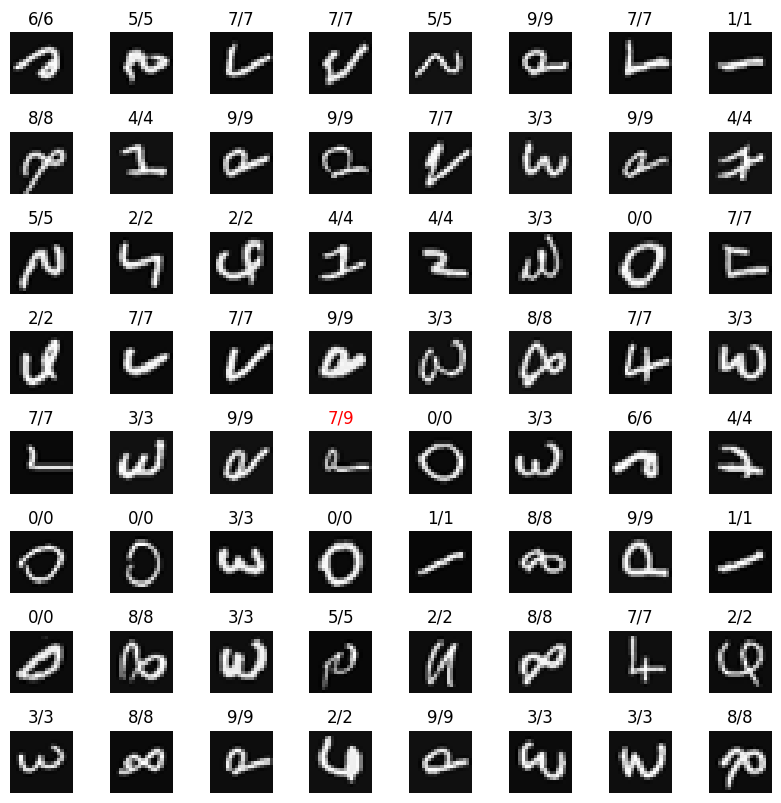

In [ ]:
model.eval()
correct = 0
total = 0
X_test = torch.from_numpy(x_test).view(-1, 1, 20, 20)

# 2. 将标签压平 -> (1000,)
# PyTorch 的 CrossEntropyLoss 需要标签是一维的长整型
y_label = y_test.squeeze()

torch.no_grad()
z = model(X_test)
_, y_hat = torch.max(z.data, 1)
total = y_test.shape[0]
correct += (y_hat == y_label).sum().item()

print("Accuracy: %d %%" % (100 * correct / total))

m, _ = x_test.shape
fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1)
for _,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    x_random_reshaped = x_test[random_index].reshape((20,20))
    
    # Display the image
    ax.imshow(x_random_reshaped, cmap='gray')
    
    # Display the label above the image
    ax.set_title(
        f'{y_hat[random_index]}/{y_test[random_index]}',
        color = f'{'black' if y_hat[random_index] == y_test[random_index] else 'red'}'
    )
    ax.set_axis_off()
